<br>

---

<br>

### 4️⃣ Бэкенды: одна команда — разные движки отрисовки

`Plots.jl` — это не библиотека рисования, а **единый интерфейс** к нескольким
графическим движкам. Сам `Plots` решает, *что* нарисовать; рисует —
**бэкенд**.

Практический смысл: код `plot(x, y)` вы пишете один раз, а движок меняете одной
строкой — под задачу.

| Бэкенд | Включается | Сильная сторона |
|---|---|---|
| GR | `gr()` | быстрый, по умолчанию, хорош для статики и PNG/PDF |
| PlotlyJS | `plotlyjs()` | интерактивность: зум, панорамирование, подсказки |
| UnicodePlots | `unicodeplots()` | рисует прямо в терминале текстом |

> 📌 Смена бэкенда **не меняет ваш код** — меняется только то, чем он
> отрисовывается. Именно ради этого `Plots.jl` и существует.

## 🎯 После этого занятия вы сможете

- строить графики с помощью `Plots.jl`;
- добавлять серии данных, подписи осей и заголовки;
- переключать бэкенды и понимать, зачем они нужны;
- создавать простую анимацию.

<br>

---

<br>

### **2️⃣ Plots.jl в Julia - универсальная библиотека для визуализации данных.**

`Plots.jl` — это мощная и гибкая библиотека для построения графиков в языке программирования **Julia**. Она предоставляет единый интерфейс для работы с разными бекендами визуализации и упрощает создание графиков.

##### **🔹 Основные возможности `Plots.jl`**

✅ **Поддержка различных бекендов**: `GR`, `PyPlot`, `Plotly`, `PGFPlotsX`, `UnicodePlots` и другие. 

✅ **Гибкость и модульность**: позволяет переключаться между бекендами без изменения кода.  

✅ **Простота использования**: интуитивный синтаксис, удобный для быстрого построения графиков.

✅ **Интерактивность**: поддержка интерактивных графиков (например, с Plotly).  

✅ **Поддержка анимации**: создание анимированных графиков.  

✅ **Интеграция с DataFrames.jl** и другими библиотеками анализа данных.  


##### **📌 Установка `Plots.jl`**
Если библиотека еще не установлена, ее можно установить через `Pkg`:

In [1]:
# Plots уже входит в окружение курса (Project.toml), поэтому его достаточно
# подключить. Про установку пакетов и временные окружения — занятие 7.
using Plots

#### **📈 Простейший пример построения графика**

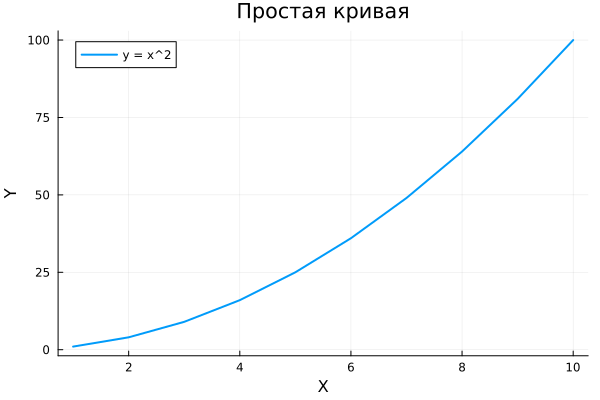

In [2]:
using Plots

x = 1:10
y = x .^ 2  # Квадрат значений x

plot(x, y, label="y = x^2", title="Простая кривая", xlabel="X", ylabel="Y", lw=2)

- `plot(x, y)` – создание линейного графика.
- `label="y = x^2"` – подпись графика.
- `title`, `xlabel`, `ylabel` – добавление заголовка и подписей осей.
- `lw=2` – толщина линии.

<br>

---

<br>

### 3️⃣ `plot` и `plot!` — как добавлять серии на график

Это центральное соглашение `Plots.jl`, и оно опирается на общее правило Julia
из **занятия 6**.

- **`plot(...)`** создаёт **новый** график и возвращает объект графика.
- **`plot!(...)`** **изменяет уже существующий** график, добавляя в него серию.

Восклицательный знак — **часть имени функции**, а не синтаксис языка.
Julia не проверяет и не обеспечивает изменяемость: `!` — это соглашение,
которым авторы пакетов предупреждают, что функция меняет свой аргумент.
Ничто не мешает написать функцию с `!`, которая ничего не меняет, — просто так
не делают.

#### Явная форма: передаём объект графика

В обучающем коде лучше работать с объектом явно. Так видно, **что именно**
изменяется:

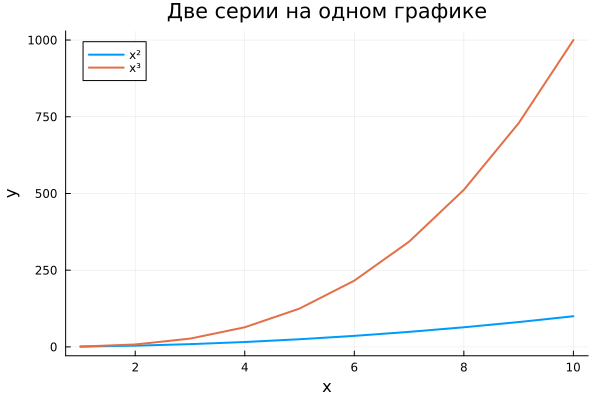

In [3]:
using Plots
gr()

x  = 1:10
y1 = x .^ 2
y2 = x .^ 3

p = plot(x, y1, label = "x²", lw = 2)     # создали график, сохранили в p
plot!(p, x, y2, label = "x³", lw = 2)     # ДОБАВИЛИ вторую серию в тот же p

title!(p, "Две серии на одном графике")
xlabel!(p, "x")
ylabel!(p, "y")

p                                          # показываем результат

Объект графика — обычное значение Julia, его можно проверять как любое другое:

In [4]:
@show typeof(p)
@show length(p.series_list)     # сколько серий сейчас на графике — должно быть 2

typeof(p) = Plots.Plot{Plots.GRBackend}


length(p.series_list) = 2


2

#### Неявная форма: «текущий график»

В интерактивной работе объект часто не передают — тогда `plot!` дописывает
серию в **текущий** график, тот, что был создан последним:

```julia
plot(x, y1, label = "x²")     # стал текущим
plot!(x, y2, label = "x³")    # добавилось СЮДА ЖЕ
```

Это удобно в REPL, но в скриптах и в учебном коде опасно: достаточно вставить
между строками ещё один `plot`, и серия уйдёт не туда. **В этом занятии мы
почти везде передаём объект явно.**

#### А если нужны два независимых графика?

Тогда просто два вызова `plot` — и никакого `plot!`:

length(pa.series_list) = 1
length(pb.series_list) = 1


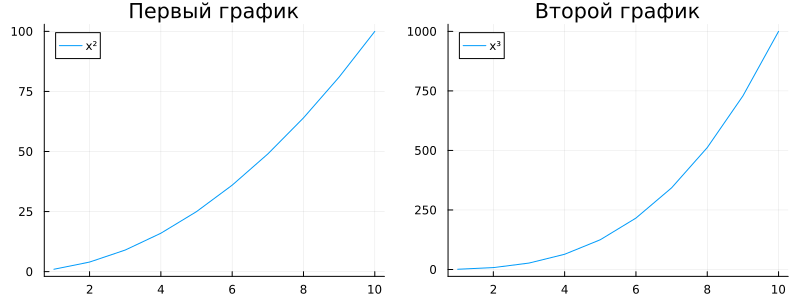

In [5]:
pa = plot(x, y1, label = "x²",  title = "Первый график")
pb = plot(x, y2, label = "x³",  title = "Второй график")

@show length(pa.series_list)    # 1 — серии не смешались
@show length(pb.series_list)    # 1

plot(pa, pb, layout = (1, 2), size = (800, 300))   # показать рядом

> 📌 **Итог.** `plot` — создать, `plot!` — дополнить. То же правило работает
> для всей библиотеки: `scatter`/`scatter!`, `xlabel!`, `ylabel!`, `title!`,
> `xflip!` — все они изменяют существующий график.

#### Несколько серий одним вызовом

Если серии известны заранее, их можно передать матрицей — каждый столбец
станет отдельной серией:

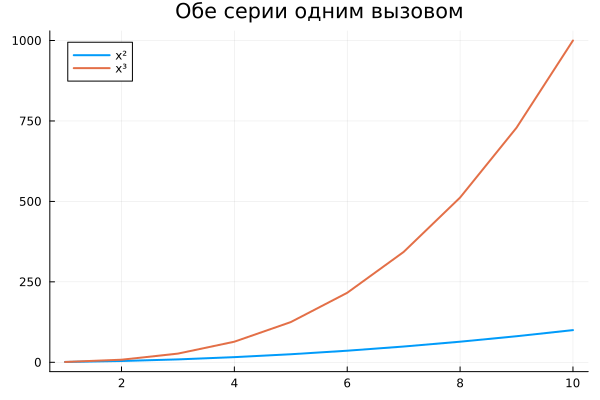

In [6]:
plot(x, [y1 y2], label = ["x²" "x³"], lw = 2, title = "Обе серии одним вызовом")

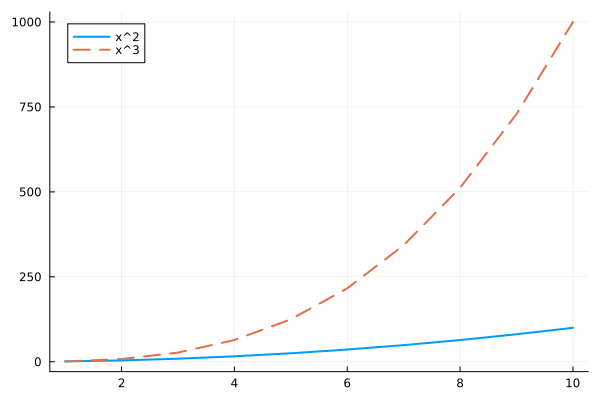

In [7]:
x = 1:10
y1 = x .^ 2
y2 = x .^ 3

plot(x, y1, label="x^2", lw=2)

#`plot!` добавляет новый график к текущему:
plot!(x, y2, label="x^3", lw=2, linestyle=:dash)



#### **🎞 Создание анимации**

[ Info: Saved animation to ~/Introduction-to-Julia/animation.gif


Plots.AnimatedGif("~/Introduction-to-Julia/animation.gif")
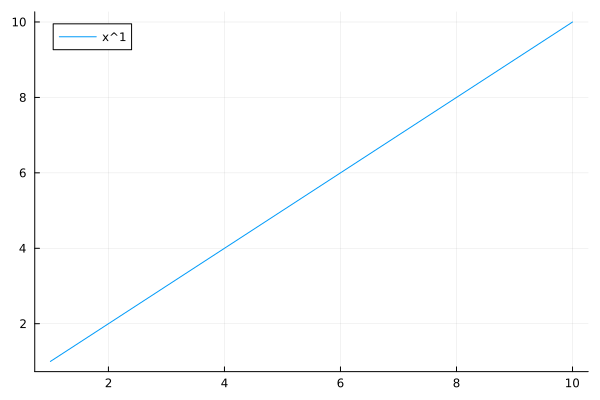

In [8]:
anim = @animate for i in 1:20
    plot(1:10, (1:10) .^ i, label="x^$i")
end

gif(anim, "animation.gif", fps=5)

##### **📌 Заключение**

`Plots.jl` — это универсальная библиотека, подходящая как для быстрых визуализаций, так и для сложных анимаций и интерактивных графиков. Благодаря поддержке различных бекендов, она дает максимальную гибкость для различных задач.

🚀 **Если вам нужна мощная и удобная библиотека для визуализации в Julia, `Plots.jl` — отличный выбор!**

<br>

---

<br>

### **3️⃣ Использование `Plots.jl` с разными бэкендами в Julia.**

**`Plots.jl`** — это мощная и гибкая библиотека для построения графиков в языке программирования **Julia**. Она предоставляет **единый интерфейс** для работы с разными бэкендами визуализации, что позволяет легко переключаться между ними без изменения кода.


#### **🎨 Что такое бэкенды в `Plots.jl`?**  

Бэкенды — это движки рендеринга графиков, которые `Plots.jl` использует для отображения данных.  
Вы можете легко переключаться между бэкендами, просто вызвав соответствующую функцию.

##### **📌 Популярные бэкенды:**
1. `gr()` – быстрый и легкий, установлен по умолчанию.
2. `plotlyjs()` – интерактивные графики с поддержкой зума и панорамирования.
3. `pyplot()` – аналог Matplotlib, обеспечивает красивую визуализацию.
4. `pgfplotsx()` – использует LaTeX для создания качественных векторных графиков.
5. `unicodeplots()` – текстовые графики прямо в консоли.


##### **📥 Установка необходимых пакетов**

Перед началом убедитесь, что все библиотеки установлены:

In [9]:
# GR и PlotlyJS также входят в окружение курса.
using Plots, GR, PlotlyJS

WebIO._IJuliaInit()

#### **⚡ Использование `gr()` (бэкенд по умолчанию)**
GR — это быстрый и эффективный бэкенд, который поддерживает 2D и 3D графики.


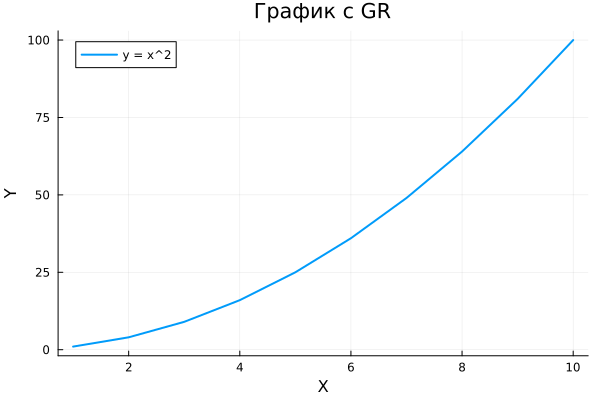

In [10]:
using Plots
gr()  # Устанавливаем бэкенд GR

x = 1:10
y = x .^ 2

plot(x, y, label="y = x^2", title="График с GR", xlabel="X", ylabel="Y", lw=2)

📌 **Преимущества `gr()`**:  

✅ Быстрый рендеринг  

✅ Хорошо подходит для статических графиков

✅ Минимальные зависимости 


<br>

#### **🌍 Использование `plotlyjs()` для интерактивных графиков**

Если вам нужны **интерактивные** графики (например, зум, панорамирование, всплывающие подсказки), попробуйте `plotlyjs()`.


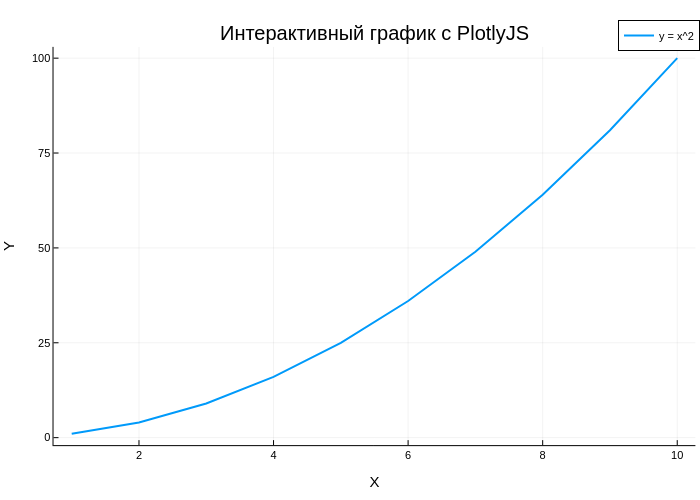

In [11]:
using Plots
plotlyjs()  # Устанавливаем интерактивный бэкенд PlotlyJS

x = 1:10
y = x .^ 2

plot(x, y, label="y = x^2", title="Интерактивный график с PlotlyJS", xlabel="X", ylabel="Y", lw=2)

📌 **Преимущества `plotlyjs()`**:  

✅ Интерактивность (зум, панорамирование).  

✅ Красивые и детализированные графики. 

✅ Возможность экспорта в HTML и PNG.

✅ Возможность интеграции с [Plotly AI .](https://go.plotly.com/smarter-ai-data-apps)

<br>

#### **🔄 Переключение между бэкендами**

В любой момент можно **переключить бэкенд**, просто вызвав его:



In [12]:
gr()          # Устанавливаем GR
plotlyjs()    # Переключаемся на PlotlyJS

Plots.PlotlyJSBackend()

Вы можете попробовать **разные бэкенды** и выбрать тот, который лучше всего подходит для вашей задачи.

##### **📌 Выводы:**

- `Plots.jl` позволяет легко переключаться между бэкендами для визуализации.
  
- **GR** – быстрый и легковесный, подходит для большинства случаев.
  
- **PlotlyJS** – отлично подходит для интерактивных графиков.
  
- Выбор бэкенда зависит от вашей задачи: если нужен **быстрый рендеринг**, используйте `gr()`, если **интерактивность**, выбирайте `plotlyjs()`.

🚀 **Попробуйте разные бэкенды и используйте тот, который вам удобнее!**

<br>

---

<br>

### **4️⃣ Научное исследования связи между глобальной 🌍 температурой и количеством 🏴‍☠️ пиратов.** 

В целях научного исследования 😃 давайте используем этот блокнот, чтобы изучить связь между глобальной температурой и количеством пиратов примерно между 1860 и 2000 годами.
Это исследование будет иллюстрировать интересную (но шуточную) корреляцию между ростом глобальной температуры и снижением числа пиратов. 

#### **Описание переменных:**

- `globaltemperatures` — список средних **глобальных температур** (в градусах Цельсия) за определенные периоды.
  
- `numpirates` — количество **пиратов**, существовавших в соответствующие годы.

Этот пример часто используется в статистике для демонстрации **ложных корреляций** (когнитивного искажения, когда два несвязанных явления выглядят связанными). 

Хотите построить график этой зависимости в Julia? 📊

In [13]:
globaltemperatures = [14.4, 14.5, 14.8, 15.2, 15.5, 15.8] # в градусах Цельсия
numpirates = [45000, 20000, 15000, 5000, 400, 17]; # количество пиратов

<br>

Как мы уже рассмотрели выше, **Plots** поддерживает несколько бэкендов — то есть библиотек, которые фактически выполняют рисование — все с одним и тем же **API** 😃. 

Для начала давайте попробуем использовать бэкенд **GR**— мощный графический бэкенд, который позволяет создавать профессиональные графики.

Выбираем и вызываем его с помощью команды `gr()`:

In [14]:
gr() # используем графический пакет GR

Plots.GRBackend()

**и теперь мы можем использовать такие команды, как `plot` и `scatter`, для создания наших графиков 📊**

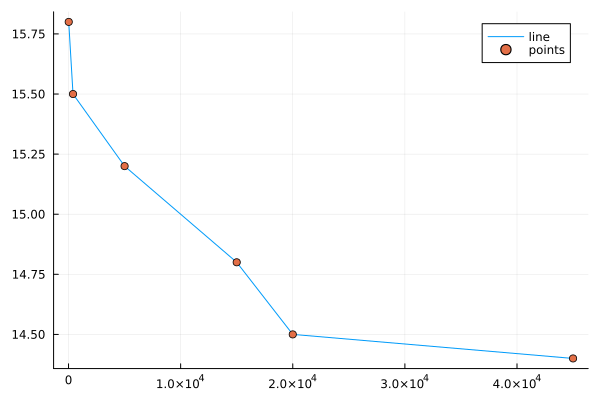

In [15]:
plot(numpirates, globaltemperatures, label="line")  # построение графика
scatter!(numpirates, globaltemperatures, label="points") # добавление точек

- `!` в конце имени функции `scatter!` делает `scatter!` мутирующей функцией, указывая, что рассеянные точки будут добавлены к уже существующему графику.

- Напротив, посмотрите, что произойдет, если заменить `scatter!` в приведенном выше примере на немутирующую функцию `scatter`.

- Далее давайте обновим этот график с помощью команд `xlabel!`, `ylabel!` и `title!`, чтобы добавить больше информации к нашему графику.

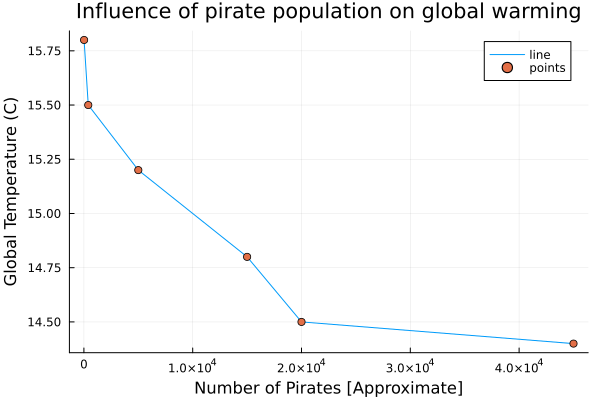

In [16]:
xlabel!("Number of Pirates [Approximate]") # название оси x
ylabel!("Global Temperature (C)") # название оси y
title!("Influence of pirate population on global warming") # название графика

Это все еще выглядит не совсем правильно. Количество пиратов уменьшилось с 1860 года, поэтому чтение графика слева направо похоже на взгляд назад во времени, а не вперед. Давайте перевернем ось x, чтобы лучше увидеть, как популяция пиратов вызвала изменение глобальной температуры с течением времени!

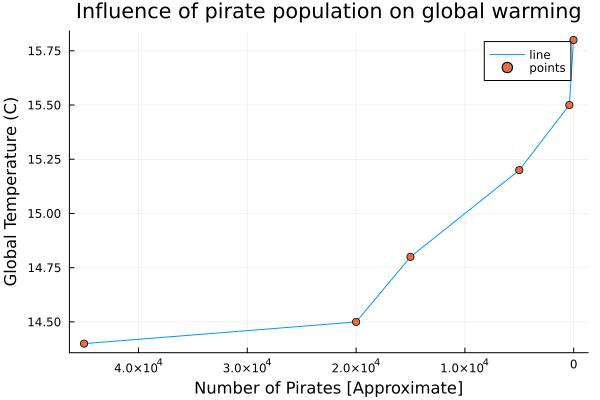

In [17]:
xflip!() # разворачивает график по оси x

И вот оно! Ура-а-а!

Примечание: у нас возникли некоторые сомнения по поводу этого упражнения. :) Это шутка о том, как люди часто путают корреляцию и причинно-следственную связь.


<br>

---

<br>

### **5️⃣ Текстовый графический пакет `UnicodePlots` .**

`UnicodePlots` — текстовый графический пакет, который строит **ASCII**-графики прямо в терминале.

<br>

**Не меняя синтаксис, мы можем создать этот график с помощью бэкэнда UnicodePlots в терминале**

In [18]:
# UnicodePlots в окружение курса НЕ входит: он нужен только для этой
# необязательной демонстрации. Ставим его во временное окружение,
# чтобы не менять зависимости курса.
using Pkg
курс = dirname(Pkg.project().path)
Pkg.activate(; temp = true)
Pkg.add(["UnicodePlots", "Plots"])
using UnicodePlots

  Activating 

new project at `/tmp/jl_vKBlr8`


   Resolving 

package versions...


    Updating `/tmp/jl_vKBlr8/Project.toml`
  [91a5bcdd] + Plots v1.41.7
  [b8865327] + UnicodePlots v3.8.4
    Updating `/tmp/jl_vKBlr8/Manifest.toml`
  

[66dad0bd] + AliasTables v1.1.3
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.1
  [d38c429a] + Contour v0.6.3
  [a8cc5b0e] + Crayons v4.2.0
  [9a962f9c] + DataAPI v1.16.0
  [864edb3b] + DataStructures v0.19.6
  [8bb1440f] + DelimitedFiles v1.9.1
  [ffbed154] + DocStringExtensions v0.9.5
  [c87230d0] + FFMPEG v0.4.5
⌅ [53c48c17] + FixedPointNumbers v0.8.6
  [1fa38f19] + Format v1.3.7
  [28b8d3ca] + GR v0.73.27
  [92d709cd] + IrrationalConstants v0.2.6
  [1019f520] + JLFzf v0.1.11
  [692b3bcd] + JLLWrappers v1.8.0
  [682c06a0] + JSON v1.8.0
  [b964fa9f] + LaTeXStrings v1.4.1
  [23fbe1c1] + Latexify v0.16.12
  [2ab3a3ac] + LogExpFunctions v1.0.1
  [1914dd2f] + MacroTools v0.5.16
  [299715c1] + MarchingCubes v0.1.11
  [442fdcdd] + Measures v0.3.3
  [e1d29d7a] + Missings v1.2.0
  [77ba4419] + NaNMath v1.1.4
  [bac558e1] + OrderedCollections v2.0.1
  [69de0a69] + Parsers v3.0.0
  [ccf2f8ad] + PlotThem

[ Info: Precompiling UnicodePlots [b8865327-cd53-5732-bb35-84acbb429228] (cache misses: wrong dep version loaded (4))


┌ Warning: Module StatsBase with build ID fafbfcfd-d6c1-394c-0000-127f46b5f090 is missing from the cache.
│ This may mean StatsBase [2913bbd2-ae8a-5f71-8c99-4fb6c76f3a91] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Info: Skipping precompilation due to precompilable error. Importing UnicodePlots [b8865327-cd53-5732-bb35-84acbb429228].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.


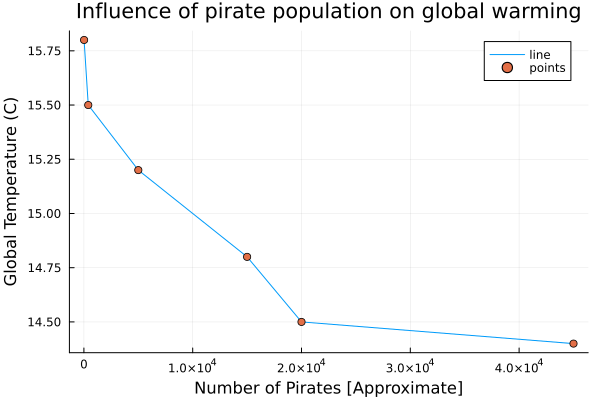

In [19]:
plot(numpirates, globaltemperatures, label="line")  # построение графика
scatter!(numpirates, globaltemperatures, label="points") # добавление точек
xlabel!("Number of Pirates [Approximate]") # название оси x
ylabel!("Global Temperature (C)") # название оси y
title!("Influence of pirate population on global warming") # название графика

***Обратите внимание, как этот второй график отличается от первого! Использование такого текста немного глупо в блокноте Jupyter, где у нас есть возможности для рисования, но это может быть очень полезно для быстрой и грубой визуализации в терминале.***

<br>

---

<br>

## 🔹 **Упражнения:**

#### ✅ Задание 8.1

Дано:
```julia
x = -10:10
```
Постройте график y против x для $y = x^2$. Возможно, вам захочется снова изменить бэкенды.

In [20]:
# Ваше решение:



##### Правильное решение:

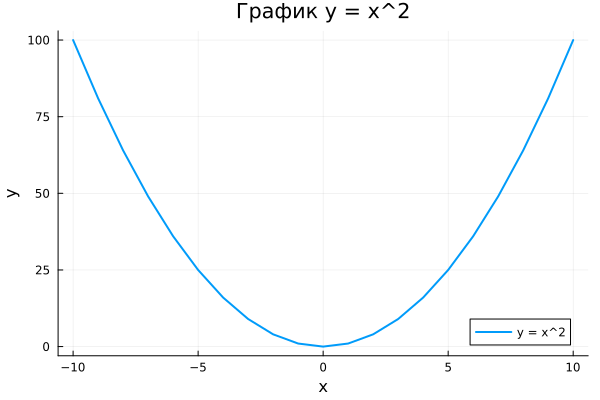

In [21]:
using Plots # Подключаем пакет Plots для построения графиков

gr()  # Устанавливаем GR как бэкенд для графиков

# Определяем данные
x = -10:10
y = x .^ 2  # Элементное возведение в квадрат

# Построение графика с использованием GR
plot(x, y, label="y = x^2", xlabel="x", ylabel="y", title="График y = x^2", lw=2, grid=true)


In [22]:
using UnicodePlots # Используем пакет UnicodePlots

# Определяем данные
x = -10:10
y = x .^ 2  # Возведение каждого элемента x в квадрат

# Построение ASCII-графика
lineplot(x, y, title="y = x^2", xlabel="x", ylabel="y")


         ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀y = x^2⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀ 
         ┌────────────────────────────────────────┐ 
     100 │⢇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡸│ 
         │⠘⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⠃│ 
         │⠀⢱⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⡎⠀│ 
         │⠀⠀⢣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡜⠀⠀│ 
         │⠀⠀⠈⢆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡸⠀⠀⠀│ 
         │⠀⠀⠀⠘⡆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢰⠃⠀⠀⠀│ 
         │⠀⠀⠀⠀⠘⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⠃⠀⠀⠀⠀│ 
   y     │⠀⠀⠀⠀⠀⠘⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠇⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠘⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠎⠀⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠀⠘⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠎⠀⠀⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠀⠀⠘⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⠊⠀⠀⠀⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⢆⠀⠀⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⠀⠀⡔⠃⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠣⡄⠀⠀⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⠀⠀⡠⠎⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
         │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⢄⠀⠀⠀⠀⠀⡇⠀⠀⠀⠀⢀⠎⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
       0 │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠢⠤⣀⣀⣇⣀⡠⠤⠊⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
         └────────────────────────────────────────┘ 
         ⠀-10⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀

#### ✅ Задание 8.2 
Выполните следующий код

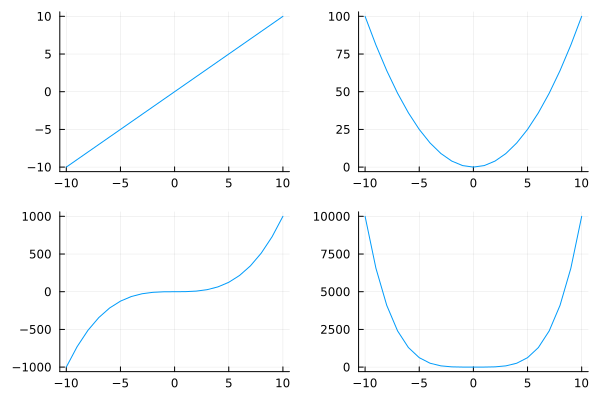

In [23]:
p1 = plot(x, x)
p2 = plot(x, x.^2)
p3 = plot(x, x.^3)
p4 = plot(x, x.^4)
plot(p1, p2, p3, p4, layout = (2, 2), legend = false)

а затем создайте график размером $4х1$, который использует `p1`, `p2`, `p3` и `p4` в качестве подграфиков.

In [24]:
# Ваше решение:


**Решение задачи:**


Для начала мы создадим 4 отдельных графика, а затем разместим их в двух разных макетах:

1. 2×2 макет (задан в коде задания)

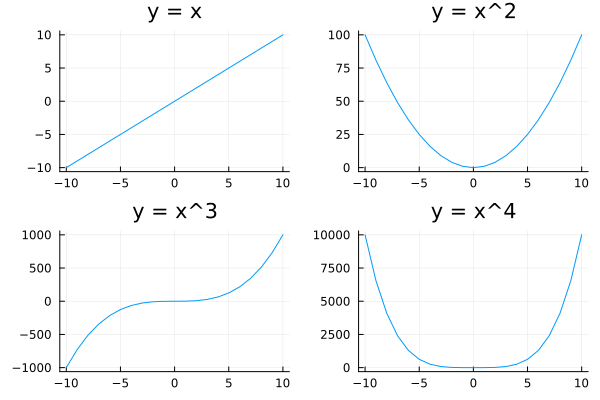

In [25]:
using  UnicodePlots

# Определяем данные
x = -10:10

# Создаем подграфики
p1 = plot(x, x, title="y = x")
p2 = plot(x, x.^2, title="y = x^2")
p3 = plot(x, x.^3, title="y = x^3")
p4 = plot(x, x.^4, title="y = x^4")

# Вывод графиков в макете 2×2
plot(p1, p2, p3, p4, layout=(2, 2), legend=false)


2. **Теперь создадим для 4×1 макета (вертикальное расположение):**

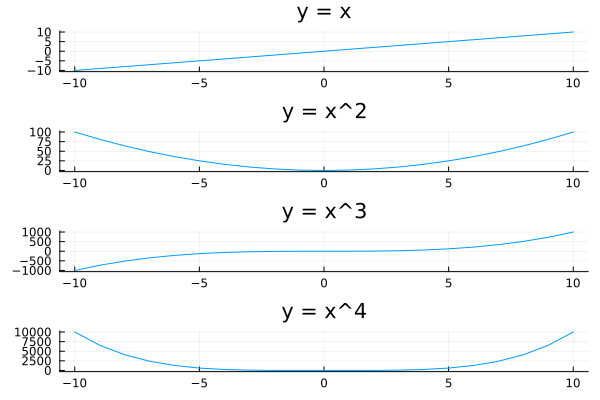

In [26]:
# Вывод графиков в макете 4×1 (вертикальный стек)
plot(p1, p2, p3, p4, layout=(4, 1), legend=false)


##### **Выводы по задаче 8.2**  

🔹 **Использование макетов в `Plots.jl`**  
- В Julia с `Plots.jl` можно легко комбинировать несколько графиков с помощью параметра `layout`.  
- Мы рассмотрели **два способа расположения графиков**:  
  - **(2×2)** – более **компактное представление**, полезное, когда хочется видеть все графики сразу.  
  - **(4×1)** – **вертикальное расположение**, которое делает каждый график **более разборчивым**, но занимает больше места.  

🔹 **Анализ графиков**  
- Функции \( y = x \), \( y = x^2 \), \( y = x^3 \) и \( y = x^4 \) показывают разные степени роста:  
  - Линейная зависимость \( y = x \) растет равномерно.  
  - Квадратичная \( y = x^2 \) возрастает быстрее.  
  - Кубическая \( y = x^3 \) и четвертая степень \( y = x^4 \) еще стремительнее увеличиваются, особенно при больших x.  
- Чем выше степень \( n \), тем более **крутое возрастание** функции при положительных x и более **резкое падение** при отрицательных x.

🔹 **Практическое применение**  
- Использование различных макетов помогает **оптимизировать визуализацию данных**.  
- Вертикальный `4×1` макет удобен для **подробного изучения** каждой функции, а `2×2` – для **быстрого сравнения**.  
- Этот метод построения графиков может использоваться в **анализе данных, научных исследованиях и машинном обучении**.

<br>

✅ **Вывод**:  

Макеты позволяют **эффективно сравнивать разные функции**, а выбор конкретного варианта зависит от задачи: **компактность** или **детализация**.

<br>

#### ✅ Задание 8.3 — Построить график и дополнить его

Постройте график и добавьте в него вторую серию, работая с объектом **явно**.

1. Постройте синус на `xs`, сохраните объект графика в `pfig`,
   подпишите серию `"sin"`.
2. Добавьте в **тот же** объект косинус с подписью `"cos"`.
3. Задайте заголовок `"Синус и косинус"` и подписи осей.
4. В `n_series` запишите количество серий на итоговом графике.

Графический результат проверить `@assert`-ом нельзя, поэтому проверка смотрит
на **структуру объекта**: сколько серий, как они подписаны, каков заголовок.
Посмотрите на сам рисунок глазами — он должен содержать две кривые.

In [27]:
using Plots
gr()

xs = range(0, 2π, length = 200)

0.0:0.03157379551346526:6.283185307179586

In [28]:
# Ваше решение

**Правильное решение:**

n_series = 2

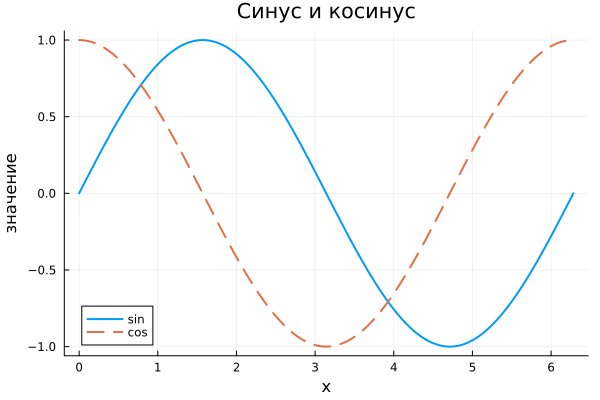

In [29]:
# Правильное решение

# plot создаёт график и возвращает объект — сохраняем его.
pfig = plot(xs, sin.(xs), label = "sin", lw = 2)

# plot! дополняет ИМЕННО этот объект, потому что мы передали его первым аргументом.
plot!(pfig, xs, cos.(xs), label = "cos", lw = 2, ls = :dash)

title!(pfig, "Синус и косинус")
xlabel!(pfig, "x")
ylabel!(pfig, "значение")

n_series = length(pfig.series_list)

@show n_series
pfig

Если бы во второй строке стоял `plot`, а не `plot!`, вы получили бы **новый**
график с одной лишь косинусоидой, а синус потерялся бы. В этом вся разница.

In [30]:
# Структурная проверка объекта графика
@assert n_series == 2                  "на графике должно быть ровно две серии"

labels = [s[:label] for s in pfig.series_list]
@assert "sin" in labels                "первая серия должна называться sin"
@assert "cos" in labels                "вторая серия должна называться cos"
@assert pfig[:plot_title] == "Синус и косинус" || pfig.subplots[1][:title] == "Синус и косинус"

# А вот так выглядит ошибка, которую ловит это задание:
wrong = plot(xs, sin.(xs), label = "sin")
wrong = plot(xs, cos.(xs), label = "cos")     # plot вместо plot! — синус потерян
@assert length(wrong.series_list) == 1        "второй plot создал НОВЫЙ график"

println("✔ Задание 8.3 выполнено")

✔ Задание 8.3 выполнено


<br>

---

<br>

## 📝 Итоги занятия

| Действие | Функция |
|---|---|
| Создать график | `plot(x, y)` |
| Добавить серию | `plot!(p, x, y)` |
| Точечная диаграмма | `scatter`, `scatter!` |
| Заголовок и оси | `title!`, `xlabel!`, `ylabel!` |
| Несколько панелей | `plot(p1, p2, layout = (m, n))` |
| Сменить движок | `gr()`, `plotlyjs()`, `unicodeplots()` |
| Анимация | `@animate` + `gif` |

**Что важно унести:**

1. `!` в конце имени — **соглашение**, а не механизм языка. Julia не проверяет,
   что функция что-то меняет; `!` предупреждает читателя.
2. `plot` создаёт, `plot!` дополняет. В скриптах передавайте объект графика
   явно — так вы не зависите от того, какой график сейчас «текущий».
3. Бэкенд меняет только отрисовку, а не ваш код.

---

[← Седьмое занятие. Пакеты](07%20-%20Packages.ipynb) | [Оглавление](README.md) | [Девятое занятие. Множественная диспетчеризация →](09%20-%20Multiple%20dispatch.ipynb)